## Exercise

Download a monthly sea surface temperature (SST) time series for the Mediterranean Sea from [surftemp.net](https://surftemp.net/timeseries/index.html) in CSV format. Choose a geographic area of your choice.

Once the data is loaded:

- Visualise the series and identify the trend and seasonality.
- Prepare the data using a sliding window and sequential train/test split.
- Train an RNN with PyTorch to predict the SST of the following month.
- Evaluate the model with MAE, RMSE, and MAPE and visualise the predictions.


[Sample data](link)

In [2]:
import numpy as np
import torch
import torch.nn as nn

import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error


In [3]:
df = pd.read_csv("SST_ABSO_002.00E_004.00E_38.00N_40.00N_19800101_20251231_timeseries.csv", header=2)
print(df.columns)
print(df.shape)

Index(['year', 'month', 'day', 'mean temperature kelvin',
       'mean temperature deg C', 'mean temperature uncertainty',
       'fraction of sea-ice-covered ocean'],
      dtype='str')
(3312, 7)


In [4]:
X_features = df[['year', 'month', 'day', 'mean temperature uncertainty']].values
X_target = df[['mean temperature deg C']].values

# Scalers independents
scaler_features = MinMaxScaler()
scaler_target   = MinMaxScaler()

features_scaled = scaler_features.fit_transform(X_features)
target_scaled   = scaler_target.fit_transform(X_target)

n_train = int(df.shape[0]*0.8)

features_train = features_scaled[:n_train,:]
features_test = features_scaled[n_train:,:]

target_train = target_scaled[:n_train,:]
target_test = target_scaled[n_train:,:]


print(features_train.shape)
print(target_test.shape)

(2649, 4)
(663, 1)


In [5]:
def create_sequences(features,target, window_size):
    X, y = [], []
    for i in range(window_size, len(features)):
        X.append(features[i-window_size:i])
        y.append(target[i])
    return np.array(X), np.array(y)

WINDOW_SIZE = 12
X_train, y_train = create_sequences(features_train, target_train,  WINDOW_SIZE)
X_test, y_test  = create_sequences(np.concatenate([features_train[-WINDOW_SIZE:], features_test]), np.concatenate([target_train[-WINDOW_SIZE:], target_test]), WINDOW_SIZE)

print(X_train.shape)
print(y_train.shape)

(2637, 12, 4)
(2637, 1)


In [6]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).squeeze()
y_test  = torch.tensor(y_test,  dtype=torch.float32).squeeze()

In [7]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([2637, 12, 4]) torch.Size([2637])
torch.Size([663, 12, 4]) torch.Size([663])


In [8]:
class RNNModel(nn.Module):
    def __init__(self, input_size=4, hidden_size=32, num_layers=1):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])  # agafem l'últim pas temporal i el processam per una capa tipus MLP
        return out.squeeze()


In [9]:
model = RNNModel(hidden_size=64)

criterion = nn.MSELoss() # En aquest cas la funció de pèrdua és de regressió
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 1000
for epoch in range(epochs):
    model.train()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.6f}")

Epoch 50/1000 - Loss: 0.055224
Epoch 100/1000 - Loss: 0.034233
Epoch 150/1000 - Loss: 0.029181
Epoch 200/1000 - Loss: 0.025168
Epoch 250/1000 - Loss: 0.021996
Epoch 300/1000 - Loss: 0.006250
Epoch 350/1000 - Loss: 0.003631
Epoch 400/1000 - Loss: 0.002822
Epoch 450/1000 - Loss: 0.002577
Epoch 500/1000 - Loss: 0.002378
Epoch 550/1000 - Loss: 0.002280
Epoch 600/1000 - Loss: 0.002184
Epoch 650/1000 - Loss: 0.002113
Epoch 700/1000 - Loss: 0.002096
Epoch 750/1000 - Loss: 0.002012
Epoch 800/1000 - Loss: 0.001969
Epoch 850/1000 - Loss: 0.001968
Epoch 900/1000 - Loss: 0.001904
Epoch 950/1000 - Loss: 0.001876
Epoch 1000/1000 - Loss: 0.002056


In [10]:
model.eval()
with torch.no_grad():
    predictions = model(X_test)

# Desnormalització
print(predictions.numpy().reshape(-1, 1).shape)
print(y_test.numpy().reshape(-1, 1).shape)
predictions_real = scaler_target.inverse_transform(predictions.numpy().reshape(-1, 1))
y_test_real = scaler_target.inverse_transform(y_test.numpy().reshape(-1, 1))

mae  = mean_absolute_error(y_test_real, predictions_real)
rmse = np.sqrt(np.mean((y_test_real - predictions_real) ** 2))
mape = np.mean(np.abs((y_test_real - predictions_real) / y_test_real)) * 100

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
 #print(f"MAPE: {mape:.2f}%")


(663, 1)
(663, 1)
MAE:  0.68
RMSE: 0.87


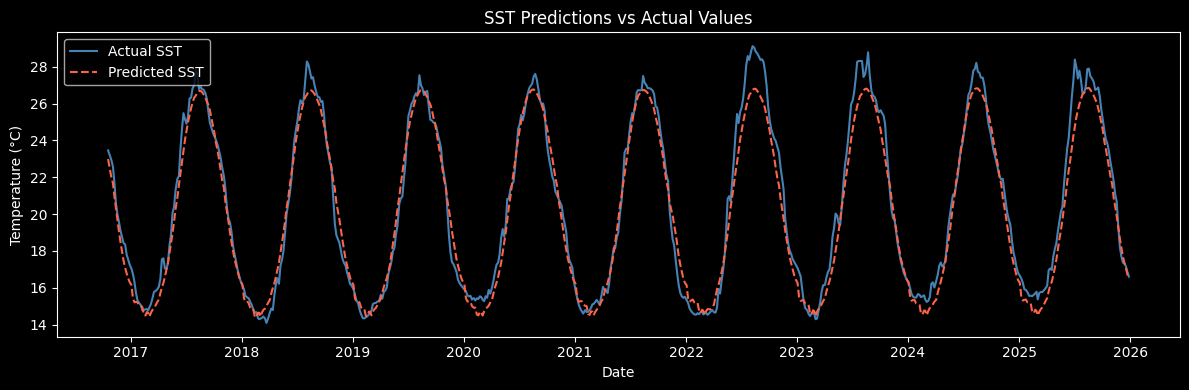

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Construcció de l'eix temporal a partir de les columnes year, month, day
dates = pd.to_datetime(df[['year', 'month', 'day']])

plt.figure(figsize=(12, 4))
plt.plot(dates[n_train:], y_test_real, label='Actual SST', color='steelblue')
plt.plot(dates[n_train:], predictions_real, label='Predicted SST', color='tomato', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('SST Predictions vs Actual Values')
plt.legend()
plt.tight_layout()
plt.show()